In [2]:
import os
import torch
DATA_FILE = "/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv"
seed = 0
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Lab Notes

**Data Preprocessing**
1. Lowercase the review
2. Remove noisy signal like <br>
3. Remove stop words: In, What, etc. which are not as informative
4. Use nltk word_tokenize, not simply split words by space but using some splitting mechanisms preformed by NLTK tokenizer. For example, don't -> do and n't
5. Lemmatize each token. Basically reduc a word to its base form. Best->good

Model is Many to One

# 1) EDA

Number of samples:  50000
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


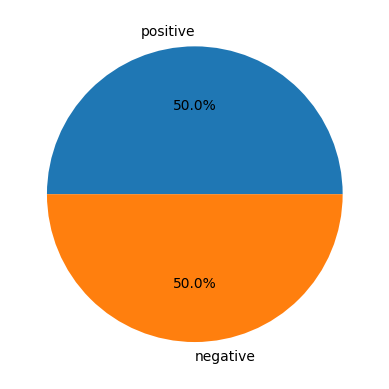

In [3]:
import pandas as pd
from matplotlib import pyplot as plt

df = pd.read_csv(DATA_FILE)

print("Number of samples: ", len(df))
print(df.head(5))
print()
print(df['sentiment'].value_counts())

plt.pie(df['sentiment'].value_counts(), labels=df['sentiment'].unique().tolist(), autopct='%1.1f%%')
plt.show()

In [4]:
import numpy as np
import nltk
import seaborn as sns

from nltk import tokenize

lenght = len(df['review'][0])
print(f'Length of a sample review: {lenght}')
word_count = df['review'][0].split()
print(f'Word count in a sample review: {len(word_count)}')
avg_len_0 = np.mean([len(sent) for sent in tokenize.sent_tokenize(df['review'][0])])
print(f'Average length of the sentences in a sample review: {avg_len_0}')

Length of a sample review: 1761
Word count in a sample review: 307
Average length of the sentences in a sample review: 175.2


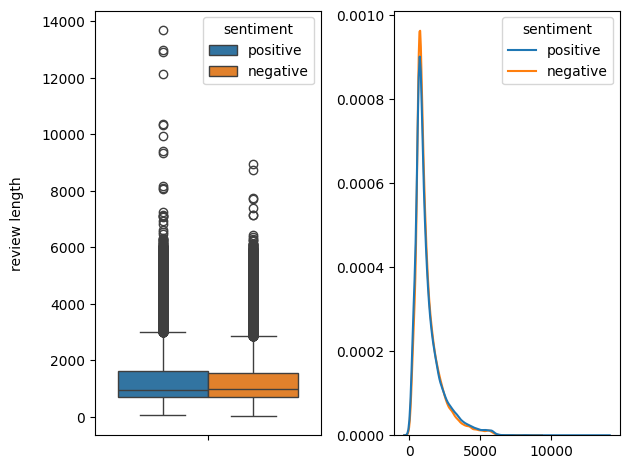

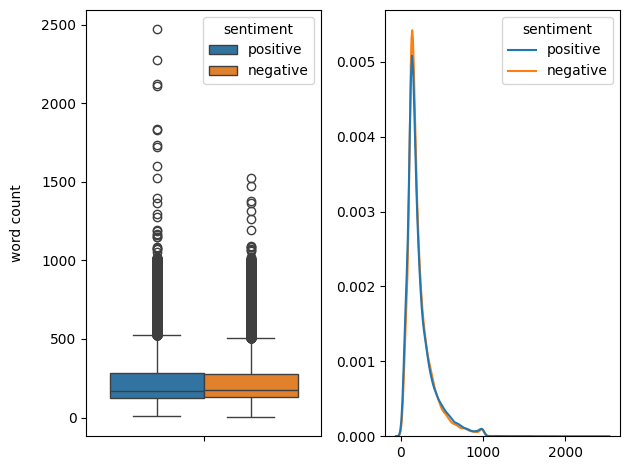

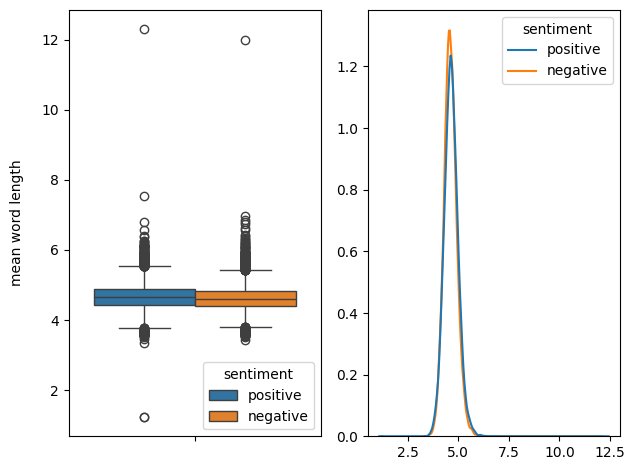

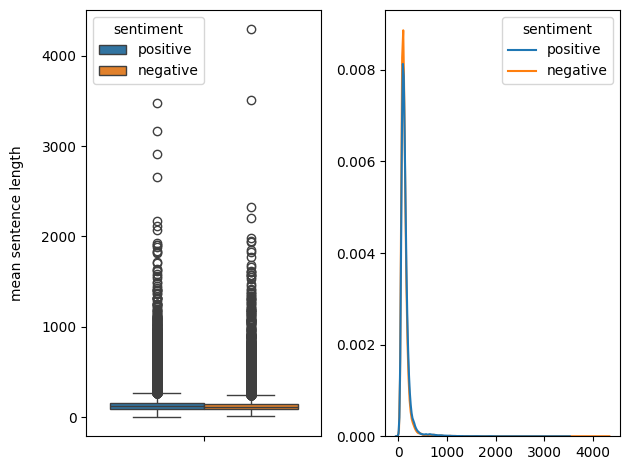

In [5]:
def visualize(data, label):
    
    print()
    plt.subplot(1,2,1)
    sns.boxplot(y=data, hue=df['sentiment'])
    plt.ylabel(label, labelpad=12.5)
    
    plt.subplot(1,2,2)
    sns.kdeplot(x=data, hue=df['sentiment'], common_norm=False)
    plt.xlabel('')
    plt.ylabel('')

    plt.subplots_adjust(wspace=0.4)
    plt.tight_layout()
    plt.show()
    
def word_count(review):
    review_list = review.split()
    return len(review_list)

eda_length = df['review'].str.len()
eda_word_count = df['review'].apply(lambda x: len(x.split()))
eda_mean_word_length = df['review'].map(lambda rev: np.mean([len(word) for word in rev.split()]) if len(rev.split()) > 0 else 0)
eda_mean_sent_length = df['review'].map(lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]) if len(tokenize.sent_tokenize(rev)) > 0 else 0)

visualize(eda_length, "review length")
visualize(eda_word_count, "word count")
visualize(eda_mean_word_length, "mean word length")
visualize(eda_mean_sent_length, "mean sentence length")

## Term Frequency Analysis

                                              review sentiment
0  one reviewers mentioned watching 1 oz episode ...  positive
1  wonderful little production filming technique ...  positive
2  thought wonderful way spend time hot summer we...  positive
3  basically theres family little boy jake thinks...  negative
4  petter matteis love time money visually stunni...  positive
5  probably all-time favorite movie story selfles...  positive
6  sure would like see resurrection dated seahunt...  positive
7  show amazing fresh innovative idea 70s first a...  negative
8  encouraged positive comments film looking forw...  negative
9  like original gut wrenching laughter like movi...  positive

Corpus length: 6035330


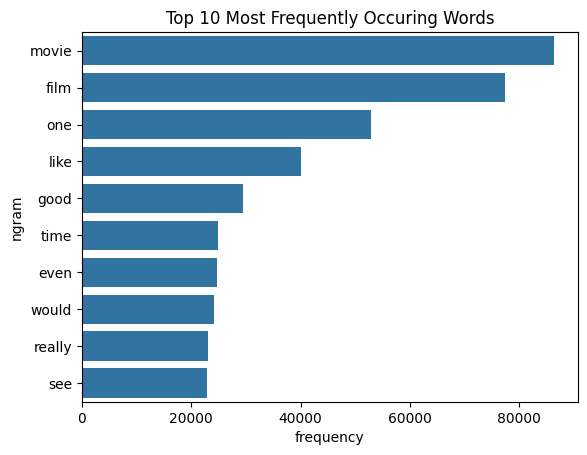

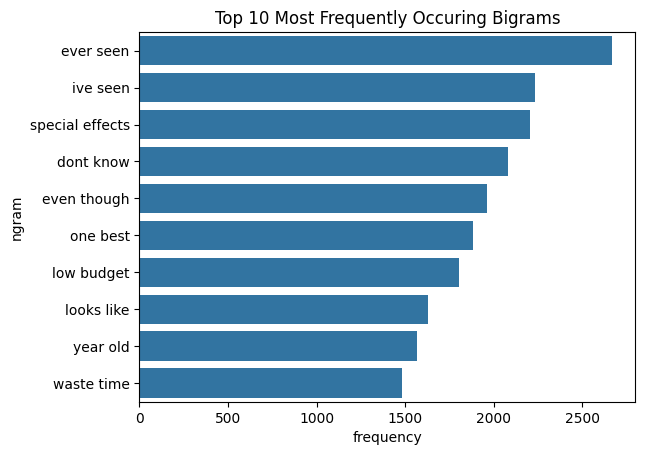

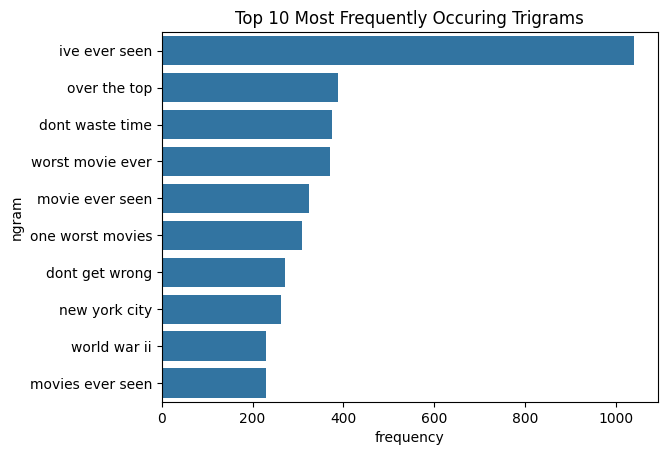

In [6]:
import re
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

stop_words = set(stopwords.words('english'))

def clean(review):
    review = review.lower()
    review = re.sub(r'<br\s*/?>', ' ', review)
    review = re.sub(r'[^a-z0-9\s-]', '', review)
    words = [word for word in review.split() if word not in stop_words]
    return " ".join(words)

def corpus(text):
    text_list = text.split()
    return text_list

def plot_ngrams(n=2, title='Top 10 Bigrams'):
    cv = CountVectorizer(ngram_range=(n, n))
    
    ngram_matrix = cv.fit_transform(df['review'])
    
    counts = ngram_matrix.sum(axis=0).A1
    
    words = cv.get_feature_names_out()
    ngram_freq = pd.DataFrame({'ngram': words, 'frequency': counts})  
    ngram_freq = ngram_freq.sort_values(by='frequency', ascending=False).head(10)

    sns.barplot(data=ngram_freq, x='frequency', y='ngram')
    plt.title(title)
    plt.show()

df['review'] = df['review'].apply(clean)
print(df.head(10))
print()

df['review_lists'] = df['review'].apply(corpus)
all_words = [word for sublist in df['review_lists'] for word in sublist]
print(f'Corpus length: {len(all_words)}')

plot_ngrams(1, 'Top 10 Most Frequently Occuring Words')
plot_ngrams(2, 'Top 10 Most Frequently Occuring Bigrams')
plot_ngrams(3, 'Top 10 Most Frequently Occuring Trigrams')
plt.show()

# 2) Data Preprocessing and Loading

In [7]:
from nltk.stem import WordNetLemmatizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

BATCH_SIZE = 128

class IMDBDataset(Dataset):
    def __init__(self, reviews, labels, max_vocab=5000, max_len=200, word_to_idx=None):
        self.max_len = max_len
        
        # Build vocab
        if word_to_idx is None:
            all_words = ' '.join(reviews).split()
            word_counts = Counter(all_words)
            self.vocab = sorted(word_counts, key=word_counts.get, reverse=True)[:max_vocab]
            
            self.word_to_idx = {word: i+2 for i, word in enumerate(self.vocab)}
            self.word_to_idx['<PAD>'] = 0
            self.word_to_idx['<UNK>'] = 1
        else:
            self.word_to_idx = word_to_idx
        
        # Tokenize and Padding
        self.sequences = torch.LongTensor([self._tokenize_and_pad(r) for r in reviews])
        self.labels = torch.tensor(labels.astype(np.int64), dtype=torch.long)
        
    def _tokenize_and_pad(self, text):
        tokens = text.split()
        seq = [self.word_to_idx.get(t, 1) for t in tokens][-self.max_len:]
        return [0] * (self.max_len - len(seq)) + seq

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Lemmatize
lemmatizer = WordNetLemmatizer()
def lemmatize_words(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])
df["review"] = df["review"].apply(lambda text: lemmatize_words(text))

# Map target to numbers
target_classes = df['sentiment'].unique()
df['y'] = df['sentiment'].map({'positive': 1.0, 'negative': 0.0})

# Split and preprocess
train_df, test_df = train_test_split(df, test_size=0.2, random_state=0)
train_df, val_df = train_test_split(train_df, test_size=0.25, random_state=0)
train_reviews = train_df['review'].values
train_labels = train_df['y'].values
val_reviews = val_df['review'].values
val_labels = val_df['y'].values
test_reviews = test_df['review'].values
test_labels = test_df['y'].values

max_len = 100
train_dataset = IMDBDataset(train_reviews, train_labels, max_vocab=5000, max_len=max_len)
val_dataset = IMDBDataset(val_reviews, val_labels, max_len=max_len, word_to_idx=train_dataset.word_to_idx)
test_dataset = IMDBDataset(test_reviews, test_labels, max_len=max_len, word_to_idx=train_dataset.word_to_idx)

# DataLoaders, for loading data in batches and shuffling for training
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True, num_workers=os.cpu_count())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=os.cpu_count())

print(f"Classes: {target_classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")

Classes: ['positive' 'negative']
Training samples: 30000
Validation samples: 10000
Test samples: 10000


# 3) Define RNN Model

## a) Custom RNN

In [ ]:
# ============================================================================
# CUSTOM RNN MODEL (Manual Implementation using nn.Linear)
# ============================================================================
# Instead of using PyTorch's built-in nn.RNN, we manually implement the
# vanilla RNN cell using nn.Linear layers. This helps us understand exactly
# what happens inside an RNN at each time step.
#
# Architecture:
#   1. Embedding Layer: Converts token indices -> dense vectors (embed_size)
#   2. Manual RNN Cell: At each time step t, computes:
#        h_t = tanh(W_hx * x_t + W_hh * h_{t-1} + b_h)
#      We implement this using two nn.Linear layers:
#        - i2h: maps input x_t (embed_size) -> hidden_size  (W_hx * x_t + b_hx)
#        - h2h: maps hidden h_{t-1} (hidden_size) -> hidden_size  (W_hh * h_{t-1})
#      Then we add them and apply tanh activation.
#   3. Fully Connected Layer: Maps final hidden state h_T -> output_size (2 classes)
#
# The key insight: we loop through the sequence manually, updating the hidden
# state one time step at a time. This is equivalent to "unrolling" the RNN.
# ============================================================================

import torch.nn as nn

class CustomRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(CustomRNN, self).__init__()
        
        self.hidden_size = hidden_size
        
        # --- Embedding Layer ---
        # Converts integer token indices into dense vectors of size embed_size.
        # e.g., token index 42 -> a learned vector of length 128
        # This is essentially a lookup table that is trained end-to-end.
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # --- Manual RNN Cell (using nn.Linear layers) ---
        # i2h: "input-to-hidden" — transforms the current input x_t
        #   Maps from embed_size -> hidden_size
        #   This corresponds to W_hx * x_t + b_hx in the RNN equation
        self.i2h = nn.Linear(embed_size, hidden_size)
        
        # h2h: "hidden-to-hidden" — transforms the previous hidden state h_{t-1}
        #   Maps from hidden_size -> hidden_size
        #   This corresponds to W_hh * h_{t-1} in the RNN equation
        # Note: bias=False because i2h already provides one bias term,
        # and having two biases is redundant (they'd just be added together)
        self.h2h = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # --- tanh activation ---
        # Used instead of ReLU because:
        #   1. Outputs are bounded in [-1, 1], preventing exploding activations
        #      from repeated multiplication with W_hh across time steps
        #   2. Outputs are zero-centered, avoiding the "zig-zagging" gradient
        #      problem that ReLU causes (all-positive outputs force all weight
        #      gradients to share the same sign)
        self.tanh = nn.Tanh()
        
        # --- Fully Connected Output Layer ---
        # Maps the final hidden state h_T to output_size (2 for binary classification)
        # The output is raw logits (not probabilities) — softmax is handled by
        # nn.CrossEntropyLoss during training
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len) — each element is a token index
        batch_size = x.size(0)
        
        # Step 1: Convert token indices to dense embeddings
        # embedded shape: (batch_size, seq_len, embed_size)
        embedded = self.embedding(x)
        
        # Step 2: Initialize hidden state h_0 to zeros
        # This is the "blank slate" before seeing any input
        # Shape: (batch_size, hidden_size)
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # Step 3: Manually loop through each time step in the sequence
        # This is the "unrolled" RNN — we process one token at a time
        for t in range(embedded.size(1)):  # iterate over seq_len
            # Get the input at time step t
            # x_t shape: (batch_size, embed_size)
            x_t = embedded[:, t, :]
            
            # Apply the RNN equation: h_t = tanh(W_hx * x_t + W_hh * h_{t-1})
            # i2h(x_t): W_hx * x_t + b_hx  -> shape (batch_size, hidden_size)
            # h2h(h_t): W_hh * h_{t-1}      -> shape (batch_size, hidden_size)
            # Sum them, then apply tanh
            h_t = self.tanh(self.i2h(x_t) + self.h2h(h_t))
        
        # Step 4: Use the FINAL hidden state h_T for classification
        # This is the "many-to-one" configuration: the entire review is
        # summarized into a single vector h_T, which we classify
        # output shape: (batch_size, output_size=2)
        output = self.fc(h_t)
        
        return output

## b) PyTorch Built-In RNN

In [ ]:
# ============================================================================
# PYTORCH BUILT-IN RNN MODEL (using nn.RNN)
# ============================================================================
# This model does the same thing as CustomRNN above, but uses PyTorch's
# optimized nn.RNN module instead of manual nn.Linear layers.
#
# nn.RNN internally implements the same equation:
#   h_t = tanh(W_ih * x_t + b_ih + W_hh * h_{t-1} + b_hh)
#
# Advantages of nn.RNN over manual implementation:
#   - Optimized C++/CUDA kernels (faster on GPU)
#   - Handles batching and sequence processing more efficiently
#   - Uses cuDNN acceleration when available
# ============================================================================

import torch.nn as nn

class TorchRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(TorchRNN, self).__init__()
        
        self.hidden_size = hidden_size
        
        # Embedding Layer: converts token indices to dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # PyTorch Built-in RNN
        # input_size=embed_size: each input token is an embed_size-dimensional vector
        # hidden_size=hidden_size: the hidden state has hidden_size dimensions
        # num_layers=1: single hidden layer (as required by the lab)
        # batch_first=True: input/output shape is (batch, seq_len, features)
        # nonlinearity='tanh': same activation as our manual implementation
        self.rnn = nn.RNN(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            nonlinearity='tanh'
        )
        
        # Fully Connected Output Layer: maps final hidden state -> 2 classes
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size = x.size(0)
        
        # Step 1: Embed the input tokens
        # embedded shape: (batch_size, seq_len, embed_size)
        embedded = self.embedding(x)
        
        # Step 2: Initialize hidden state h_0
        # Shape for nn.RNN: (num_layers, batch_size, hidden_size)
        # nn.RNN expects an extra leading dimension for num_layers
        h_0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)
        
        # Step 3: Pass through the RNN
        # nn.RNN returns:
        #   - output: hidden states at ALL time steps, shape (batch, seq_len, hidden_size)
        #   - h_n: hidden state at the LAST time step, shape (num_layers, batch, hidden_size)
        # We only need h_n for many-to-one classification
        output, h_n = self.rnn(embedded, h_0)
        
        # Step 4: Extract the final hidden state and classify
        # h_n shape: (1, batch_size, hidden_size) -> squeeze to (batch_size, hidden_size)
        output = self.fc(h_n.squeeze(0))
        
        return output

# 4) Define LSTM Model

## a) Custom LSTM

In [ ]:
# ============================================================================
# CUSTOM LSTM MODEL (Manual Implementation using nn.Linear)
# ============================================================================
# LSTMs solve the vanishing gradient problem of vanilla RNNs.
# The key innovation is the CELL STATE (c_t) — a "highway" for information
# that uses ADDITIVE updates, allowing gradients to flow backward unchanged.
#
# LSTM has THREE gates (all use sigmoid -> [0,1]) and one candidate (tanh):
#   - Forget Gate (f_t):  What to ERASE from old cell state
#   - Input Gate (i_t):   What NEW info to WRITE to cell state
#   - Output Gate (o_t):  What to OUTPUT from cell state to h_t
#   - Candidate (g_t):    The proposed new information
#
# Equations:
#   f_t = sigmoid(W_f * [h_{t-1}, x_t] + b_f)
#   i_t = sigmoid(W_i * [h_{t-1}, x_t] + b_i)
#   o_t = sigmoid(W_o * [h_{t-1}, x_t] + b_o)
#   g_t = tanh(W_g * [h_{t-1}, x_t] + b_g)
#   c_t = f_t * c_{t-1} + i_t * g_t     <-- ADDITIVE update (like ResNet!)
#   h_t = o_t * tanh(c_t)
# ============================================================================

class CustomLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(CustomLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        
        # Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # --- LSTM Gates (each has input-to-hidden and hidden-to-hidden transforms) ---
        
        # Forget Gate: f_t = sigmoid(W_f_i * x_t + W_f_h * h_{t-1} + b_f)
        # Controls what to FORGET from the previous cell state c_{t-1}
        # f_t near 1 = keep memory, f_t near 0 = erase memory
        self.forget_i2h = nn.Linear(embed_size, hidden_size)
        self.forget_h2h = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Input Gate: i_t = sigmoid(W_i_i * x_t + W_i_h * h_{t-1} + b_i)
        # Controls what NEW information to WRITE to the cell state
        # i_t near 1 = write candidate, i_t near 0 = ignore candidate
        self.input_i2h = nn.Linear(embed_size, hidden_size)
        self.input_h2h = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Candidate: g_t = tanh(W_g_i * x_t + W_g_h * h_{t-1} + b_g)
        # The proposed new information to potentially add to cell state
        # Uses tanh to keep values in [-1, 1]
        self.candidate_i2h = nn.Linear(embed_size, hidden_size)
        self.candidate_h2h = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Output Gate: o_t = sigmoid(W_o_i * x_t + W_o_h * h_{t-1} + b_o)
        # Controls what to OUTPUT from cell state to hidden state h_t
        # o_t near 1 = expose cell state, o_t near 0 = hide it
        self.output_i2h = nn.Linear(embed_size, hidden_size)
        self.output_h2h = nn.Linear(hidden_size, hidden_size, bias=False)
        
        # Activation functions
        self.sigmoid = nn.Sigmoid()  # For gates: squash to [0,1] for "gating"
        self.tanh = nn.Tanh()        # For candidate and cell state output
        
        # Fully Connected Output Layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size = x.size(0)
        
        # Step 1: Embed the input tokens
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        
        # Step 2: Initialize BOTH hidden state h_0 AND cell state c_0 to zeros
        # LSTM has TWO states (unlike vanilla RNN which only has h):
        #   - h_t: short-term memory (what the network "outputs" at each step)
        #   - c_t: long-term memory (the internal "memory bank")
        h_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        c_t = torch.zeros(batch_size, self.hidden_size).to(x.device)
        
        # Step 3: Loop through each time step
        for t in range(embedded.size(1)):
            x_t = embedded[:, t, :]  # Current input: (batch_size, embed_size)
            
            # Forget Gate: decide what to erase from old cell state
            f_t = self.sigmoid(self.forget_i2h(x_t) + self.forget_h2h(h_t))
            
            # Input Gate: decide what new info to write
            i_t = self.sigmoid(self.input_i2h(x_t) + self.input_h2h(h_t))
            
            # Candidate: the proposed new information
            g_t = self.tanh(self.candidate_i2h(x_t) + self.candidate_h2h(h_t))
            
            # Output Gate: decide what to expose from cell state
            o_t = self.sigmoid(self.output_i2h(x_t) + self.output_h2h(h_t))
            
            # Cell State Update: c_t = f_t * c_{t-1} + i_t * g_t
            # This ADDITIVE update is why LSTM solves vanishing gradients!
            # Gradient flows through '+' almost unchanged (like ResNet skip connections)
            c_t = f_t * c_t + i_t * g_t
            
            # Hidden State Update: h_t = o_t * tanh(c_t)
            h_t = o_t * self.tanh(c_t)
        
        # Step 4: Classify using the final hidden state (many-to-one)
        output = self.fc(h_t)
        
        return output

## b) PyTorch Built-In LSTM

In [ ]:
# ============================================================================
# PYTORCH BUILT-IN LSTM MODEL (using nn.LSTM)
# ============================================================================
# Same as CustomLSTM but uses PyTorch's optimized nn.LSTM module.
# nn.LSTM fuses all 4 gate computations into a single matrix multiply:
#   [i_t, f_t, g_t, o_t] = W * [h_{t-1}, x_t] + b
# This is much faster than our 8 separate nn.Linear calls.
# ============================================================================

class TorchLSTM(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size, output_size):
        super(TorchLSTM, self).__init__()
        
        self.hidden_size = hidden_size
        
        # Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_size)
        
        # PyTorch Built-in LSTM
        # input_size=embed_size: dimension of each input token embedding
        # hidden_size=hidden_size: dimension of h_t and c_t
        # num_layers=1: single LSTM layer
        # batch_first=True: input shape is (batch, seq_len, features)
        self.lstm = nn.LSTM(
            input_size=embed_size,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True
        )
        
        # Fully Connected Output Layer
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len)
        batch_size = x.size(0)
        
        # Step 1: Embed the input tokens
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)
        
        # Step 2: Initialize BOTH hidden state h_0 AND cell state c_0
        # nn.LSTM expects a tuple (h_0, c_0), each shape: (num_layers, batch, hidden_size)
        h_0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)
        c_0 = torch.zeros(1, batch_size, self.hidden_size).to(x.device)
        
        # Step 3: Pass through the LSTM
        # Returns:
        #   - output: all hidden states h_t, shape (batch, seq_len, hidden_size)
        #   - (h_n, c_n): final hidden & cell states, each (num_layers, batch, hidden_size)
        output, (h_n, c_n) = self.lstm(embedded, (h_0, c_0))
        
        # Step 4: Use final hidden state h_n for classification (many-to-one)
        # h_n shape: (1, batch_size, hidden_size) -> squeeze to (batch_size, hidden_size)
        output = self.fc(h_n.squeeze(0))
        
        return output

# 5) Training and Validation

In [ ]:
import torch.optim as optim
from tqdm import tqdm
from torchmetrics.classification import MulticlassF1Score

NUM_EPOCHS = 10

def train_step(model, train_loader, criterion, optimizer, epoch_num):
    """Train for one epoch. Returns training accuracy (%)."""
    model.train()  # Set model to training mode (enables dropout, etc.)
    
    # Track accuracy across all batches
    correct = 0
    total = 0

    for batch, (texts, labels) in enumerate(pbar := tqdm(train_loader, desc = "Epoch " + str(epoch_num), unit = "batch")):
        texts, labels = texts.to(device), labels.to(device)
        
        # Zero gradients from the previous batch (otherwise they accumulate)
        optimizer.zero_grad()
        
        # Forward pass: feed tokenized reviews through the model
        # outputs shape: (batch_size, 2) — raw logits for [negative, positive]
        outputs = model(texts)
        
        # Compute loss: CrossEntropyLoss = softmax + negative log-likelihood
        # It expects raw logits (NOT probabilities)
        loss = criterion(outputs, labels)
        
        # Backward pass: compute gradients via Backpropagation Through Time (BPTT)
        # Gradients flow backward through the unrolled time steps
        loss.backward()
        
        # Update weights using computed gradients (Adam adapts lr per parameter)
        optimizer.step()
        
        # Track accuracy: pick class with highest logit
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    accuracy = 100.0 * correct / total
    return accuracy

def val_step(model, val_loader, num_classes):
    """Evaluate on validation set. Returns accuracy (%) and macro F1-score."""
    # Initialize F1 metric (macro = unweighted mean across classes)
    f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
    
    model.eval()  # Set to eval mode (disables dropout, etc.)
    
    correct = 0
    total = 0
    
    # No gradient computation needed — saves memory and compute
    with torch.inference_mode():
        for texts, labels in val_loader:
            texts, labels = texts.to(device), labels.to(device)
            
            # Forward pass only
            outputs = model(texts)
            
            # Get predicted class
            _, predicted = torch.max(outputs, 1)
            
            # Accumulate accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update F1 metric with this batch
            f1_metric.update(predicted, labels)

    accuracy = 100.0 * correct / total
    avg_f1_score = f1_metric.compute().item()
    return accuracy, avg_f1_score

def train(model, train_loader, criterion, optimizer, num_classes, save_path: str = "best_model.pt"):
    """Full training loop. Saves best model based on validation F1-score."""
    best_val_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        # Train for one epoch
        train_acc = train_step(model, train_loader, criterion, optimizer, epoch)
        
        # Evaluate on validation set
        val_acc, val_f1 = val_step(model, val_loader, num_classes)
        
        print(f"Epoch: {epoch} | Train Acc: {train_acc:.4f} | Val acc: {val_acc:.4f} | Val f1: {val_f1:.4f}")

        # Save model checkpoint if validation F1 improved
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_f1': best_val_f1,
            }, save_path)
            print(f"--> Saved new best model with f1-score: {best_val_f1:.4f}")

# ============================================================================
# Hyperparameters (as specified in the lab manual)
# ============================================================================
vocab_size = len(train_dataset.word_to_idx)  # 5000 + PAD + UNK = 5002
embed_size = 128    # Dimension of token embeddings
hidden_size = 128   # Dimension of RNN/LSTM hidden state
output_size = 2     # Binary classification: positive vs negative
num_classes = len(target_classes)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# ============================================================================
# Train all 4 models sequentially
# ============================================================================

# --- Model 1: Custom RNN (manual nn.Linear) ---
print("=" * 60)
print("Training Model 1/4: Custom RNN (manual nn.Linear)")
print("=" * 60)
model = CustomRNN(vocab_size, embed_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader, criterion, optimizer, num_classes, save_path="best_custom_rnn.pt")

# --- Model 2: PyTorch Built-in RNN (nn.RNN) ---
print("\n" + "=" * 60)
print("Training Model 2/4: PyTorch Built-in RNN (nn.RNN)")
print("=" * 60)
model = TorchRNN(vocab_size, embed_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader, criterion, optimizer, num_classes, save_path="best_torch_rnn.pt")

# --- Model 3: Custom LSTM (manual nn.Linear) ---
print("\n" + "=" * 60)
print("Training Model 3/4: Custom LSTM (manual nn.Linear)")
print("=" * 60)
model = CustomLSTM(vocab_size, embed_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader, criterion, optimizer, num_classes, save_path="best_custom_lstm.pt")

# --- Model 4: PyTorch Built-in LSTM (nn.LSTM) ---
print("\n" + "=" * 60)
print("Training Model 4/4: PyTorch Built-in LSTM (nn.LSTM)")
print("=" * 60)
model = TorchLSTM(vocab_size, embed_size, hidden_size, output_size).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
train(model, train_loader, criterion, optimizer, num_classes, save_path="best_torch_lstm.pt")

# 6) Testing

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

def test(model, test_loader, num_classes, device):
    """Evaluate a trained model on the test set."""
    f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    with torch.inference_mode():
        for texts, labels in test_loader:
            texts, labels = texts.to(device), labels.to(device)
            
            # Forward pass
            outputs = model(texts)
            
            # Get predicted class (index of max logit)
            _, predicted = torch.max(outputs, 1)
            
            # Accumulate accuracy
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            # Update F1 metric
            f1_metric.update(predicted, labels)
            
            # Collect for confusion matrix and classification report
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = 100.0 * correct / total
    avg_f1_score = f1_metric.compute().item()
    report = classification_report(all_labels, all_preds, target_names=target_classes) 
    conf_mat = confusion_matrix(all_labels, all_preds)
    return acc, avg_f1_score, conf_mat, report

# ============================================================================
# Test all 4 models and compare results
# ============================================================================
model_configs = [
    ("Custom RNN",    CustomRNN,  "best_custom_rnn.pt"),
    ("Torch RNN",     TorchRNN,   "best_torch_rnn.pt"),
    ("Custom LSTM",   CustomLSTM, "best_custom_lstm.pt"),
    ("Torch LSTM",    TorchLSTM,  "best_torch_lstm.pt"),
]

results_summary = []
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for idx, (name, ModelClass, ckpt_path) in enumerate(model_configs):
    print("=" * 60)
    print(f"Testing: {name}")
    print("=" * 60)
    
    # Instantiate model and load best checkpoint
    test_model = ModelClass(vocab_size, embed_size, hidden_size, output_size).to(device)
    state_dict = torch.load(ckpt_path, map_location=device)
    test_model.load_state_dict(state_dict["model_state_dict"])
    print(f"Loaded from epoch {state_dict['epoch']} (best val F1: {state_dict['best_f1']:.4f})")
    
    # Evaluate on test set
    acc, f1, cm, report = test(test_model, test_loader, num_classes, device)
    
    print(f"Test Accuracy: {acc:.4f}%")
    print(f"Test F1 Score: {f1:.4f}")
    print(report)
    
    results_summary.append({"Model": name, "Accuracy (%)": f"{acc:.2f}", "F1 Score": f"{f1:.4f}"})
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_classes, 
                yticklabels=target_classes, ax=axes[idx])
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()

# Print comparison table
print("\n" + "=" * 60)
print("RESULTS COMPARISON")
print("=" * 60)
results_df = pd.DataFrame(results_summary)
print(results_df.to_string(index=False))